In [ ]:
pathOfRun = "/home/smets/codeS/fAr/runs"
jobDir = "2strNoRef"
mode = 1

In [ ]:
import os
from pyphare.pharesee.run import Run
from pyphare.pharesee.hierarchy import finest_data
import numpy as np

def getQty(job_path, job, time, qty, refine=False):
    fullPath = os.path.join(job_path, job)
    r = Run(fullPath)
    t = time        
    B = r.GetB(t)
    if qty in ("Bx","By","Bz"):
        self = B
    
    tt = np.array([])

    for ilvl, lvl in self.patch_levels.items():
        for pidx, patch in enumerate(lvl.patches):
            pdata  = patch.patch_datas[qty]
            x, v = finest_data(pdata, ilvl, self)

            if not refine: #so we are necessarily on ilvl == 0
                #print(pidx, x[()])
                #ind = np.argsort(x[(0)])
                #print(x[(0)])
                # remove the 5 ghost on each sides of the dataset
                tt = np.concatenate((tt, v[()][5:-5]), axis = None)

    return tt

In [3]:
def getMode(t, m):
    from numpy.fft import fft

    return np.absolute(fft(t)[m])

In [4]:
def get_times(path):
    import h5py
    f = h5py.File(path, "r")
    times=[]
    for k in f.keys():
        times.append(float(k.strip("t")))
    f.close()
    return np.sort(times)

fullPath = os.path.join(pathOfRun, jobDir)
h5File = os.path.join(fullPath, "EM_B.h5")
times = get_times(h5File)

gamma = 0.08664759240231287


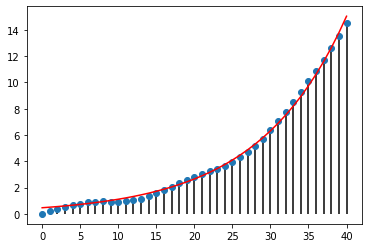

In [5]:
byz = np.array([])
linInt = [0, 41]
timesLin = times[linInt[0]:linInt[1]]
#print(timesLin)

for time in timesLin:
    by = getQty(pathOfRun, jobDir, time, "By", refine=False)
    bz = getQty(pathOfRun, jobDir, time, "Bz", refine=False)
    mm = getMode(by-1j*bz, mode)
    byz = np.append(byz, mm)

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def croaCroa(x, a, b):
    t1 = np.multiply(b, x)
    return a*np.exp(t1)

popt, pcov = curve_fit(croaCroa, timesLin, byz, p0=[0.1, 0.1])
print("gamma = {}".format(popt[1]))

plt.stem(timesLin, byz, linefmt='-k', basefmt=' ', use_line_collection=True)
plt.plot(timesLin, croaCroa(timesLin, popt[0], popt[1]), color='red')

plt.savefig("gamma.pdf")
plt.show()

In [6]:
def getPart(job_path, job, time, refine):
    fullPath = os.path.join(job_path, job)
    r = Run(fullPath)
    
    return r.GetParticles(time=time, pop_name="beam")

In [7]:
tim = 0.0

bimHier = getPart(pathOfRun, jobDir, tim, refine=False)
x = np.array([])
vx = np.array([])

zob = np.where(times == tim)
#print(zob)

In [8]:
for levelNbr, level in bimHier.levels(tim).items():
    if levelNbr == 0:
        for patchIdx, patch in enumerate(level.patches):
            dataSet = patch.patch_datas["beam_domain"].dataset
            x = np.concatenate((x, dataSet.dl[0]*(dataSet.iCells[:]+dataSet.deltas[:])), axis=None)
            vx = np.concatenate((vx, dataSet.v[:,0]), axis=None)

u = np.mean(vx)

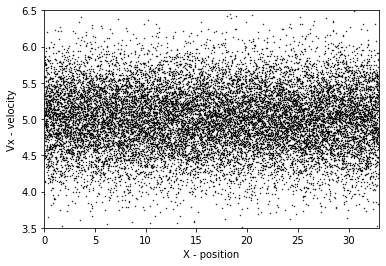

In [9]:
plt.scatter(x, vx, s=0.2, c="black")

plt.xlim([0, 33])
plt.xlabel("X - position")
plt.ylim([3.5, 6.5])
plt.ylabel("Vx - velocity")

plt.savefig("phase.pdf")

In [10]:
tv = np.array([])
vb = np.array([])

for time in times:
    bimHier = getPart(pathOfRun, jobDir, time, refine=False)
    x = np.array([])
    vx = np.array([])

    for levelNbr, level in bimHier.levels(time).items():
        if levelNbr == 0:
            for patchIdx, patch in enumerate(level.patches):
                dataSet = patch.patch_datas["beam_domain"].dataset
                x = np.concatenate((x, dataSet.dl[0]*(dataSet.iCells[:]+dataSet.deltas[:])), axis=None)
                vx = np.concatenate((vx, dataSet.v[:,0]), axis=None)

    u = np.mean(vx)

    tv = np.concatenate((tv, time), axis=None)
    vb = np.concatenate((vb, u), axis=None)
    
    
    tim = np.where(times == time)[0][0]
    print("[{:04d} / {:04d}]".format(tim, len(times)-1), end='\r')
    
    fig = plt.figure()
    ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
    ax2 = plt.subplot2grid((4, 1), (3, 0), rowspan=1)

    ax1.scatter(x, vx-u, s=0.4, c="black")

    ax1.set_xlim([0, 33])
    ax1.set_xlabel("X - position")
    ax1.set_ylim([-1.5, 1.5])
    ax1.set_ylabel("Vx - velocity")

    ax2.plot(tv, vb, color="black")
    ax2.plot(time, u, color="red", marker="o")
    ax2.set_xlim([0, times[-1]])
    ax2.set_ylim([0, 6])
    #print(times[:3], tim, times[:tim])
    
    fig.savefig("./mp4/phase_{:03d}.png".format(tim))

    plt.close(fig)

In [ ]:
import os
from pyphare.pharesee.run import Run
from pyphare.pharesee.hierarchy import finest_data
import numpy as np
import matplotlib.pyplot as plt

gray = (0.4, 0.4, 0.4)
cyan = (0.0, 0.8, 0.8)

color = {0: gray, 1: cyan}

In [ ]:
def plot_job(job_path, job, time, qty, file_idx = None,**kwargs):
    path = os.path.join(job_path, job)
    r = Run(path)
    t = time        
    B = r.GetB(t)
    if qty in ("Bx","By","Bz"):
        self = B
        
    #fig, (ax1,ax2) = plt.subplots(nrows = 2, figsize = (8, 6), sharex = True)
    fig = plt.figure()
    ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
    ax2 = plt.subplot2grid((4, 1), (3, 0), rowspan=1)

    colors = ["k", "c", "g"]
    
    tt = np.array([])

    for ilvl, lvl in self.patch_levels.items():
        for pidx, patch in enumerate(lvl.patches):
            pdata  = patch.patch_datas[qty]
            x, v = finest_data(pdata, ilvl, self)
            ax1.plot(x, v,label = "lev{} - patch{}".format(ilvl, pidx),
                     marker = 'o', markersize = 2, color = colors[ilvl])
            if ilvl == 0:
                # remove the 5 ghost on each sides of the dataset
                tt = np.concatenate((tt, v[()][5:-5]), axis = None)

    # call the scipy fft on tt

    for ilvl, lvl in B.patch_levels.items():
        for pidx, patch in enumerate(lvl.patches):
            dl = patch.dl[0]
            x0 = patch.origin[0]
            x1 = (patch.box.upper[0]+1)*dl
            ax2.plot([x0, x1], [0.5+ilvl]*2, color = color[(ilvl+pidx)%2])
            #ax2.spines['left'].set_color('none')
            #ax2.spines['right'].set_color('none')
            #ax2.spines['top'].set_color('none')
            ax2.axis('off')
            #if ilvl == 0:
            #    print(x0, x1)
            
    ax1.set_title("{} at t = {:1.6f}".format(job,t))
    ax1.set_xlim(kwargs.get("xlim", (0, 500)))
    ax1.set_ylim(kwargs.get("ylim",(-3.5, 3.5)))
    
    ax2.set_xlim(kwargs.get("xlim", (0, 500)))
    ax2.set_ylim([0, 5])

    fig.savefig("by.pdf")
    if file_idx is not None:
        fig.savefig(path+'/'+job+"_"+qty+"_{:04d}.png".format(file_idx))
        plt.close(fig)
    return fig, ax1, ax2

In [ ]:
plot_job("/home/smets/codeS/fAr/runs", "2streamNoRefine2", 20.0, "By", ylim = (-0.1, +0.1), xlim = (0.0, 33.0))